In [4]:
import sys
sys.path.append('../')
import UTILS.utils as utils
import pandas as pd
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

### SENTENCE SUBTOPIC MODELLING

In [22]:
paragraph_df = pd.read_csv("../../Data/ALL_PARAGRAPHS_CLASSED.csv")

In [57]:
# ASSIGN SENTENCES TO PARAGRAPHS
def get_all_sentences():
    all_sentences = pd.read_csv(utils.ALL_SENTENCES_DF)
    sentences_new_df = []
    for i in range (1, 101):
        chapter_paragraphs = paragraph_df[paragraph_df["chapter"] == i]
        chapter_sentences = all_sentences[all_sentences["chapter"] == i]
        for index, row in chapter_sentences.iterrows():
            this_sentence = row["text"]
            for index2, row2 in chapter_paragraphs.iterrows():
                this_paragraph = row2["text"]
            
                if this_sentence in this_paragraph:
                    new_row = {
                       "chapter" : row2["chapter"],
                        "paragraph" : row2["paragraph"],
                        "paraph_class" : row2["class"],
                        "paraph_class_name" : row2["class_name"],
                        "text" : this_sentence
                    }
                    sentences_new_df.append(new_row)
                    continue

                    
    return pd.DataFrame(sentences_new_df)

all_sentences = get_all_sentences()

In [71]:
all_sentences.to_csv("../../Data/ALL_SENTENCES_CLASSED.csv", index=False)

In [59]:
## prompts for classification

def create_huge_prompt(df, og_topic):
    prompt = "Your task will be to distill a list of topics from the following documents: \n"
    for text in df["text"].to_list():
        prompt += "DOCUMENT: {" + text + "}\n"
    prompt += """
    Your response should be a JSON in the following format: {‘topics’: [‘topic1’, ‘topic2’, ‘topic3’]}
    Topics should not be too specific, but also not too general. For example, ‘food’ is too general, but
    ‘lemon cake’ is too specific. A topic does not need to be present in multiple documents. Please do not include any city names in the topic.
    Note that these documents are all globally categorised as '""" + og_topic + "', and you should distill sub-topics from the documents assigned to that topic, not re-create a topic of the same name."
    return prompt


def create_topic_prompt(topics, og_topic):
    prompt = "Your task will be too distill a list of core topics from the following topics: \n"
    for i, topic in enumerate(topics["topics"]):
        prompt += "TOPIC " + str(i) + " : " + topic + "\n"
    prompt += """
    Your response should be a JSON in the following format: "topics": ["topic1", "topic2", "topic3"]
    Remove duplicate topics and merge topics that are too general. Merge topics together that are too
    specific. For example, ‘food’ might be too general, but ’lemon cake’ might be too specific.
    Note that these documents are all globally categorised as '""" + og_topic + "', and you should distill sub-topics of it, not re-create a topic of the same name. "
    return prompt


def create_classification_prompt(document, topics):
    prompt = "Your task will be to classify the following document into one of the following topics:"
    prompt += "\nDOCUMENT : {" + document + "}\nTOPICS:\n"
    for i, topic in enumerate(topics["topics"]):
        prompt += str(i) + " : " + topic + "\n"
    prompt += """
    Your response should be a JSON in the following format: {‘topic’: idx}
    The index should be the index of the topic in the list of topics."""
    return prompt

def extract_topic(topic):
    topic = topic.replace("'", '"')
    try :
        topic.split("\"topic\": ")[1].split("}")[0]
    except:
        print(topic)
    return (topic.split("\"topic\": ")[1].split("}")[0])

def get_text_classification(df, topics, model):
    classification = []
    for text in df["text"].to_list():
        prompt = create_classification_prompt(text, topics)
        response = model.generate_content(contents=[prompt])
        topic_num = extract_topic(response.text)
        if(topic_num is None):
            print(prompt)
            print(response.text)
        classification.append(topic_num)
    df["sentence_class"] = classification
    df["sentence_class_name"] = df["sentence_class"].apply(lambda x : topics["topics"][int(x)])
    return df

In [ ]:
from tqdm import tqdm
import json

def topic_modelling_sentences(df, model):
    final_df = pd.DataFrame()
    for i in tqdm(range(0, 25)): 
        topic_df = df[df["paraph_class"] == i]
        og_topic = df.iloc[0]["paraph_class_name"]
        prompt_1 = create_huge_prompt(topic_df, og_topic)
        response_1 = model.generate_content(contents=[prompt_1])
        topics = json.loads("".join(response_1.text.split("\n")[1:-2]))

        prompt_2 = create_topic_prompt(topics, og_topic)
        response_2 = model.generate_content(contents=[prompt_2])
        topics_reduced = json.loads("".join(response_2.text.split("\n")[1:-2]))

        text_classification_df = get_text_classification(topic_df, topics_reduced, model)
        text_classification_df.to_csv("../../Data/TOPIC_MODELLING/SENTENCE_SUBTOPICS/topic_" + str(i) + ".csv")
        final_df = pd.concat([final_df, text_classification_df])
    return final_df

In [67]:
import google.generativeai as genai

genai.configure(api_key=utils.API_KEY())
model = genai.GenerativeModel('gemini-1.5-flash')
final_df = topic_modelling_sentences(all_sentences, model)

  0%|          | 0/1 [00:00<?, ?it/s]/var/folders/yl/114pstb53sj0y8fd5bqt753r0000gn/T/ipykernel_55591/2648374526.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["sentence_class"] = classification
/var/folders/yl/114pstb53sj0y8fd5bqt753r0000gn/T/ipykernel_55591/2648374526.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["sentence_class_name"] = df["sentence_class"].apply(lambda x : topics["topics"][int(x)])
100%|██████████| 1/1 [03:46<00:00, 226.09s/it]


### TOPIC TREE

In [5]:
all_dataframes_paths = utils.get_files_in_directory("../../Data/TOPIC_MODELLING/SENTENCE_SUBTOPICS/")
all_dataframes = [pd.read_csv(x) for x in all_dataframes_paths]
subtopics_df = pd.concat(all_dataframes)

In [6]:
topic_names = subtopics_df.groupby("paraph_class_name")["text"].count().sort_values().index.to_list()
topic_count = subtopics_df.groupby("paraph_class_name")["text"].count().sort_values().to_list()

topic_names.reverse()
topic_count.reverse()

paragraph_topics = [(a, b) for a, b in zip(topic_names, topic_count)]

sentence_topics = []
for topic, count in paragraph_topics:
    sub_topics_df = subtopics_df[subtopics_df["paraph_class_name"] == topic]
    sub_topic_names = sub_topics_df.groupby("sentence_class_name")["text"].count().sort_values().index.to_list()
    sub_topic_count = sub_topics_df.groupby("sentence_class_name")["text"].count().sort_values().to_list()
    sub_topics = [(a, b) for a, b in zip(sub_topic_names, sub_topic_count)]
    sentence_topics.append(sub_topics)


In [7]:

all_rows = dict()
for i, t in enumerate(paragraph_topics):
    l = []
    for sub in sentence_topics[i]:
        l.append(sub[1])
    l.reverse()
    if "Religion" in t[0]:
        all_rows["Religion"] = l
    else:
        all_rows[t[0]] = l

In [70]:
from treelib import Node, Tree

tree = Tree()

tree.create_node("", "parent")
for i, topic in enumerate(paragraph_topics):
    node_name = topic[0] + " " + str(topic[1])
    tree.create_node(node_name, i, parent="parent")
current_index = len(paragraph_topics)
for i, subtopics in enumerate(sentence_topics):
    for subtopic in subtopics:
        node_name = subtopic[0] + " " + str(subtopic[1])
        tree.create_node(node_name, current_index, parent = i)
        current_index += 1


tree.show(key=False)


├── Family and Social Structures 2
│   ├── Religious influence on Chinese society 1
│   └── Religious persecution and social impact 1
├── Plague and Disease 3
│   ├── Death and burial customs 1
│   ├── Disease 1
│   └── Geography of mountainous regions 1
├── River Dwellers (Tankia) 5
│   └── Unique Habitats and Dwellings 5
├── Gambling and Opium 9
│   ├── Social Attitudes towards Leisure 2
│   └── Leisure and Recreation 7
├── Folk Festivals and Celebrations 13
│   └── Human Interaction with Environment 13
├── Agriculture and Farming 18
│   ├── Agriculture 9
│   └── Plant Resources 9
├── Food and Diet 23
│   ├── Cultural Foodways 4
│   ├── Food Security and Access 4
│   └── Responses to Food Scarcity 15
├── Fashion and Dress 26
│   └── Chinese Social Hierarchy and Dress Codes 26
├── Tea Production and Trade 29
│   ├── Tea Production and Trade 12
│   └── Geography, Transportation, and Culture 17
├── Cemeteries and Burial Practices 31
│   ├── Population Dynamics and Settlement Patterns 1

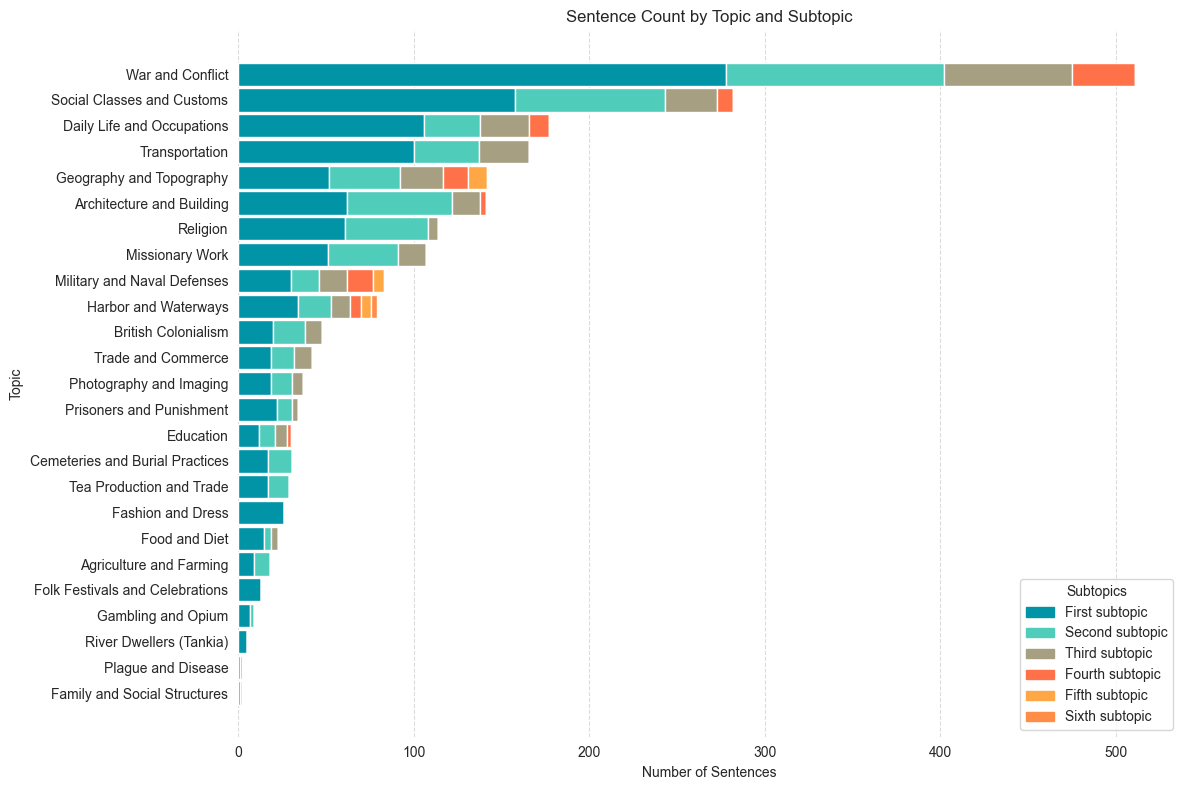

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches # Import for creating custom legend handles


raw_data_by_topic = all_rows
sns.set_style("white")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Bitstream Vera Sans', 'Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans']

transformed_data = []
for topic, subtopic_counts in raw_data_by_topic.items():
    for i, count in enumerate(subtopic_counts):
        # We assign a 'Subtopic_Rank' directly based on the list index (0-indexed).
        transformed_data.append({
            'Topic': topic,
            'Subtopic_Rank': i, # This directly serves as the rank for coloring
            'DocumentCount': count
        })

df_counts = pd.DataFrame(transformed_data)


rank_to_label = {
    0: 'First subtopic',
    1: 'Second subtopic',
    2: 'Third subtopic',
    3: 'Fourth subtopic',
    4: 'Fifth subtopic',
    5: 'Sixth subtopic',
}

custom_palette = {
    'First subtopic': '#0094a6', 
    'Second subtopic': '#4fccba', 
    'Third subtopic': '#A79F81',
    'Fourth subtopic': '#ff7148', 
    'Fifth subtopic': '#ffa745',   
    'Sixth subtopic': '#FF8C47',   

}

df_counts['Subtopic_Order_Label'] = df_counts['Subtopic_Rank'].apply(
    lambda x: rank_to_label.get(x, f'Subtopic #{x+1}')
)

max_rank_found = df_counts['Subtopic_Rank'].max()
legend_hue_labels_sorted = [rank_to_label.get(i, f'Subtopic #{i+1}') for i in range(max_rank_found + 1)]

plot_hue_order_reversed = list(legend_hue_labels_sorted) # Make a copy
plot_hue_order_reversed.reverse()

subtopic_labels_in_rank_order = sorted(df_counts['Subtopic_Order_Label'].unique(),
                                        key=lambda x: [k for k, v in rank_to_label.items() if v == x][0])

legend_display_order = list(subtopic_labels_in_rank_order) # Start with natural order
legend_display_order.reverse() # Reverse it for legend display



plot_stacking_order = list(subtopic_labels_in_rank_order) # Start with natural order
plot_stacking_order.reverse() # Reverse it for plotting



# --- 2. Create the Stacked Horizontal Bar Chart ---
plt.figure(figsize=(12, 8)) # Adjust figure size as needed

# Get the axes object to manipulate the legend later
ax = sns.histplot(
    data=df_counts,
    y='Topic',               
    weights='DocumentCount', 
    hue='Subtopic_Order_Label', 
    multiple='stack',        
    palette=custom_palette,        
    edgecolor='white',    
    shrink=0.9,            
    alpha=1, 
    hue_order=plot_stacking_order # Use the reversed order for stacking
)
sns.despine(left=True, bottom=True, top=True, right=True)



# --- Manual Legend Creation (FIX for empty legend) ---
reordered_handles = []
reordered_labels = []

for label in legend_display_order:

    if label in custom_palette and label in subtopic_labels_in_rank_order:
        color = custom_palette[label]
        patch = mpatches.Patch(color=color, label=label)
        reordered_handles.append(patch)
        reordered_labels.append(label)

reordered_handles.reverse()
reordered_labels.reverse()

ax.legend(reordered_handles, reordered_labels, title="Subtopics")


plt.title('Sentence Count by Topic and Subtopic')
plt.xlabel('Number of Sentences')
plt.ylabel('Topic')
plt.grid(axis='x', linestyle='--', alpha=0.7) 

plt.tight_layout()

plt.show()


In [14]:
df_counts

,Topic,Subtopic_Rank,DocumentCount,Subtopic_Order_Label
0,War and Conflict,0,278,First subtopic
1,War and Conflict,1,124,Second subtopic
2,War and Conflict,2,73,Third subtopic
3,War and Conflict,3,36,Fourth subtopic
4,Social Classes and Customs,0,158,First subtopic
...,...,...,...,...
72,Plague and Disease,0,1,First subtopic
73,Plague and Disease,1,1,Second subtopic
74,Plague and Disease,2,1,Third subtopic
75,Family and Social Structures,0,1,First subtopic


In [50]:
label_to_handle

{}